In [6]:
import numpy as np
import openmdao.api as om
import os

os.environ['OPENMDAO_REPORTS'] = 'none'


class aerodynamicsDis(om.ExplicitComponent):
    def setup(self):
        # Global Design Variable
        self.add_input('B', val=1.)

        # Coupling parameter
        self.add_input('phi', val=0.)

        # Coupling output
        self.add_output('L', val=0.)

    def setup_partials(self):
        # Finite difference all partials
        self.declare_partials('*', '*', method='cs')

    def compute(self, inputs, outputs):
        q = 1 # N/cm2
        C = 10 # cm
        psi = 0.05 # rad
        r = 0.9425
        theta0 = 0.26 # rad

        B = inputs['B']
        phi = inputs['phi']

        outputs['L'] = 1/1000 * q*B*C * ((2*np.pi*(phi+psi)) + r*(1-np.cos(np.pi/2*(phi+psi)/theta0)))

class structuresDis(om.ExplicitComponent):
    def setup(self):
        # Coupling parameter
        self.add_input('L', val=0.)

        # Coupling output
        self.add_output('phi', val=0.)

    def setup_partials(self):
        # Finite difference all partials
        self.declare_partials('*', '*', method='cs')

    def compute(self, inputs, outputs):
        C = 10 # cm
        p = 0.1111
        k1 = 4000 # N/cm
        k2 = 2000 # N/cm
        z1 = 0.2
        z2 = 0.7

        L = inputs['L']

        outputs['phi'] = np.remainder(( 1000*L/(k1*(1+p)) - (1000*L*p)/(k2*(1+p)) ) * ( 1/(C*(z2-z1)) ),2*np.pi)
        
class aerostructuresGroup(om.Group):
    def setup(self):
        cycle = self.add_subsystem('cycle', om.Group(), promotes=['*'])
        cycle.add_subsystem('aero', aerodynamicsDis(), promotes_inputs=['B', 'phi'],
                            promotes_outputs=['L'])
        cycle.add_subsystem('strux', structuresDis(), promotes_inputs=['L'],
                            promotes_outputs=['phi'])

        cycle.linear_solver = om.DirectSolver(rhs_checking=False)
        nlbgs = cycle.nonlinear_solver = om.NonlinearBlockGS()
        nlbgs.options['maxiter'] = 1000
        nlbgs.options['iprint'] = 0
        

In [82]:
prob = om.Problem()
prob.model = aerostructuresGroup()

prob.driver = om.ScipyOptimizeDriver()
prob.driver.options['optimizer'] = 'COBYQA'
prob.driver.options['tol'] = 1e-8
prob.driver.options['disp'] = False

prob.model.add_design_var('B', lower = 0., upper = 300.)

prob.model.approx_totals()

prob.setup()

prob.set_val('B', 233.1)

prob.run_model()

print('coupling vars')
print('L', prob.get_val('L'))
print('phi', prob.get_val('phi'))

print('iter count', 
      prob.model.cycle.aero.iter_count + prob.model.cycle.strux.iter_count)

coupling vars
L [6.22556036]
phi [0.21790302]
iter count 1726


In [25]:
prob = om.Problem()
prob.model = aerostructuresGroup()

prob.driver = om.ScipyOptimizeDriver()
prob.driver.options['optimizer'] = 'COBYQA'
prob.driver.options['tol'] = 1e-8
prob.driver.options['disp'] = False

prob.model.add_design_var('B', lower = 0., upper = 300.)

prob.model.approx_totals()

prob.setup()

bvec = np.linspace(0,300,100)
itercount = []
for b in bvec:
    prob.set_val('B', b)
    prob.run_model()
    itercount.append(prob.model.cycle.aero.iter_count + 
                     prob.model.cycle.strux.iter_count)

# print('coupling vars')
# print('L', prob.get_val('L'))
# print('phi', prob.get_val('phi'))

# print('iter count', 
#       prob.model.cycle.aero.iter_count + prob.model.cycle.strux.iter_count)

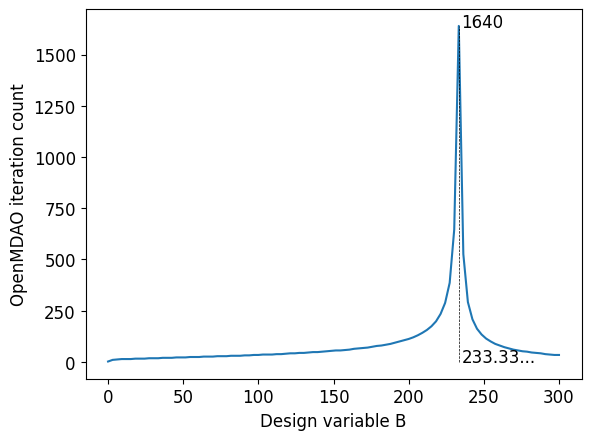

In [67]:
import matplotlib.pyplot as plt
import math

plt.plot(bvec, itercount)
maxind = np.argmax(itercount).item()
plt.vlines(bvec[maxind], 0, np.max(itercount),
           linewidth=0.5,
           linestyle='--',
           color='k')
plt.text(235,1635,
         str(np.max(itercount)))
plt.text(235,0,
         "{:.2f}...".format(bvec[maxind]))
plt.xlabel('Design variable B')
plt.ylabel('OpenMDAO iteration count')
plt.rcParams.update({'font.size':12})

In [20]:
# dog = np.linspace(0,300,50)
dog = np.random.rand(10)
np.maximum.accumulate(dog)

array([0.28264385, 0.61148473, 0.61148473, 0.78144763, 0.78144763,
       0.78144763, 0.84682812, 0.84682812, 0.84682812, 0.84682812])